In [1]:
# Import the necessary 'xarray' library for reading the file.
import xarray as xs
# Import 'numpy' for manipulation of the array.
import numpy as np
import netCDF4
import h5netcdf

In [5]:
#!pip install netCDF4 h5netcdf

In [2]:
# Load the dataset.
db = xs.open_dataset('MESH_drainage_database.nc')

In [3]:
db

<xarray.Dataset> Size: 2MB
Dimensions:       (rlat: 115, rlon: 180, NGRU: 8)
Coordinates:
    lon           (rlat, rlon) float32 83kB ...
    lat           (rlat, rlon) float32 83kB ...
    rlon          (rlat, rlon) float32 83kB ...
    rlat          (rlat, rlon) float32 83kB ...
Dimensions without coordinates: NGRU
Data variables: (12/14)
    Rank          (rlat, rlon) int32 83kB ...
    Next          (rlat, rlon) int32 83kB ...
    IAK           (rlat, rlon) int32 83kB ...
    Chnl          (rlat, rlon) int32 83kB ...
    Reach         (rlat, rlon) int32 83kB ...
    DA            (rlat, rlon) float32 83kB ...
    ...            ...
    Elev          (rlat, rlon) float32 83kB ...
    ChnlLength    (rlat, rlon) float32 83kB ...
    IntSlope      (rlat, rlon) float32 83kB ...
    GridArea      (rlat, rlon) float32 83kB ...
    GRU           (NGRU, rlat, rlon) float32 662kB ...
    rotated_pole  int32 4B ...
Attributes:
    NominalGridSize_AL:  9339.504229721293
    ContourInterval:     1.0
    ImperviousArea:      0.0
    NumRiverClasses:     7.0
    ElevConversion:      1.0
    ClassCount:          8
    TotalNumOfGrids:     11329
    NumGridsInBasin:     11328
    MinimumSlope:        1e-06
    DebugGridNo:         1

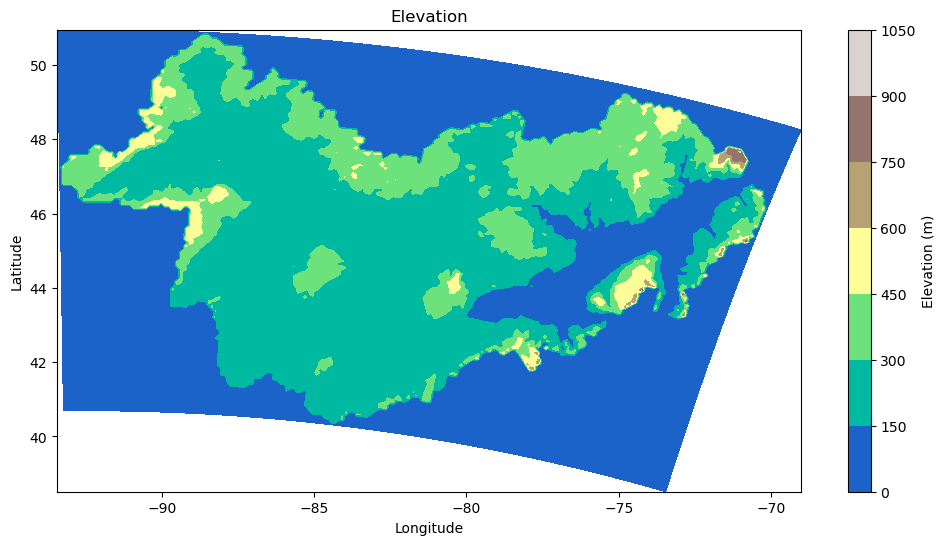

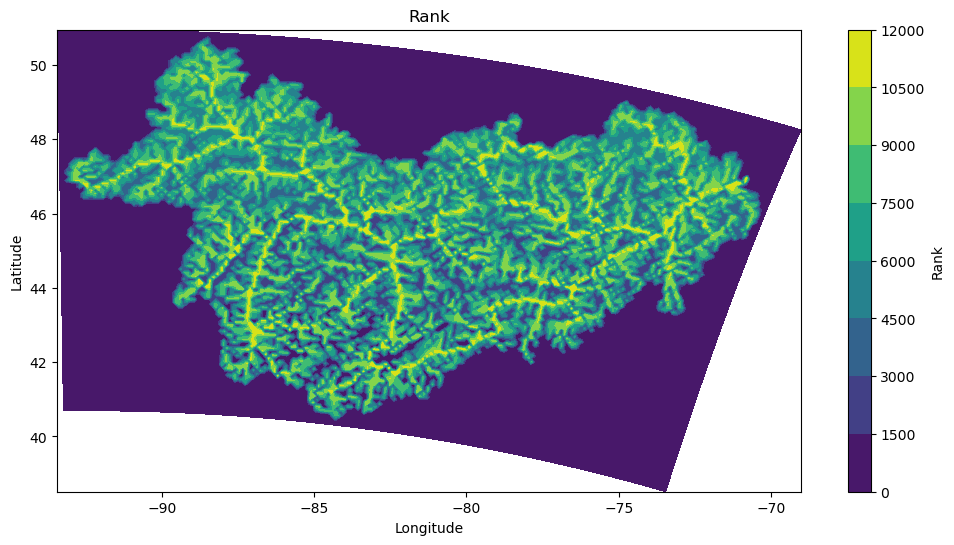

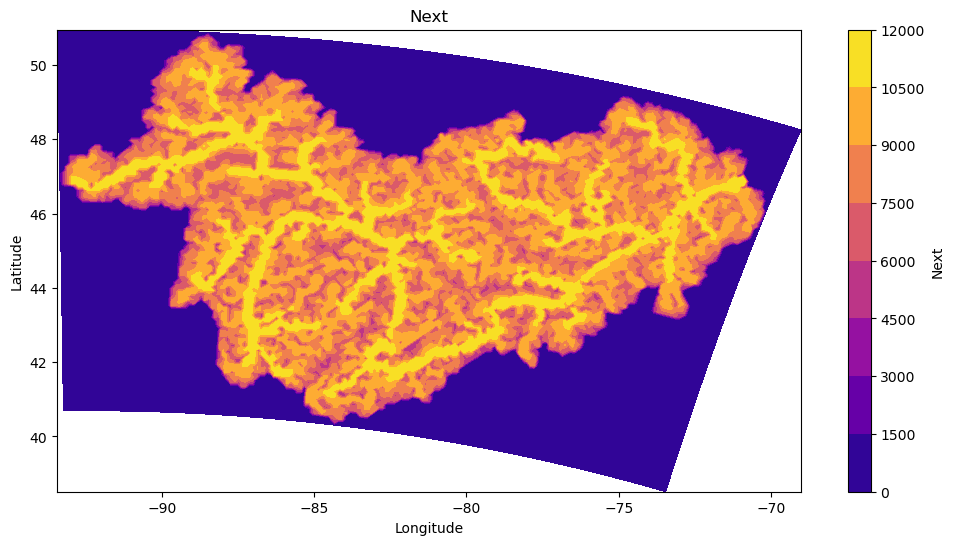

In [4]:
import xarray as xr
import matplotlib.pyplot as plt

# Load the dataset
db = xr.open_dataset('MESH_drainage_database.nc')

# Extract the required data
elevation = db['Elev']
rank = db['Rank']
next_var = db['Next']
lat = db['lat']
lon = db['lon']

# Plot the Elevation
plt.figure(figsize=(12, 6))
plt.contourf(lon, lat, elevation, cmap='terrain')
plt.colorbar(label='Elevation (m)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Elevation')
plt.show()

# Plot the Rank
plt.figure(figsize=(12, 6))
plt.contourf(lon, lat, rank, cmap='viridis')
plt.colorbar(label='Rank')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Rank')
plt.show()

# Plot the Next
plt.figure(figsize=(12, 6))
plt.contourf(lon, lat, next_var, cmap='plasma')
plt.colorbar(label='Next')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Next')
plt.show()


In [9]:
# Make a local copy of the 'Elev' variable.
elev = np.copy(db['Elev'].values)

In [10]:
# Check for repeat values.
unique_elev, unique_counts = np.unique(elev, return_counts = True)
if (len(unique_counts) or np.count_nonzero(unique_counts > 1) > 0):
    print("WARNING: Cells exist with equal elevation values. In this case, drainage direction is arbitrarily assigned 'East'.")

print(len(elev.flatten()))
print(len(unique_elev))

3276
2885


In [11]:
# Sort the list of unique elevations (and check for no elevation data, assuming all zeros).
unique_elev = np.sort(unique_elev)
if (np.count_nonzero(unique_elev) == 0):
    print("ERROR: Elevation data not found.")
    exit()

In [12]:
# Re-rank the domain by elevation (in reverse order).
current_rank = np.size(elev)
new_rank = np.zeros(np.shape(elev), dtype = 'int32')
while (True):
    if (len(unique_elev) > 0):
        loc = np.where(elev == unique_elev[0])
        if (len(loc[0]) > 0 and len(loc[1]) > 0):
            new_rank[loc[0][0], loc[1][0]] = current_rank
            current_rank -= 1
            elev[loc[0][0], loc[1][0]] = None # Reassign to skip next time
        else:
            unique_elev = np.delete(unique_elev, 0)
    else:
        break
        
#while True:
#    if len(unique_elev) > 0:
#        loc = np.where(elev == unique_elev[0])
#        if len(loc[0]) > 0 and len(loc[1]) > 0:
#            # Process the matches in reverse order
#            for i in range(len(loc[0]) - 1, -1, -1):
#                new_rank[loc[0][i], loc[1][i]] = current_rank
#                current_rank -= 1
#                elev[loc[0][i], loc[1][i]] = np.nan  # Reassign to skip next time
#        unique_elev = np.delete(unique_elev, 0)
#    else:
#        break      

# Assign the new values.
db['Rank'].values = new_rank

# Save the modified file.
db.to_netcdf('MESH_drainage_database_modified.nc')

In [ ]:
np.where(elev == unique_elev[0])

In [13]:
# THIS SCRIPT CONTINUES FROM ABOVE
# THIS SCRIPT CONTINUES FROM ABOVE
# THIS SCRIPT CONTINUES FROM ABOVE

# Save the current dimensions to a local variable (0-based).
max1 = np.shape(elev)[0] - 1
max2 = np.shape(elev)[1] - 1

# Define variables.
new_next = np.zeros(np.shape(elev), dtype = 'int32')
new_ddir = np.zeros(np.shape(elev), dtype = 'int32')
bad_next = np.zeros(np.shape(elev), dtype = 'int32')
new_iak = np.zeros(np.shape(elev), dtype = 'int32')
new_chnlslope = np.zeros(np.shape(elev), dtype = 'float32')
new_chnllength = np.zeros(np.shape(elev), dtype = 'float32')
new_chnl = np.zeros(np.shape(elev), dtype = 'int32')
new_reach = np.zeros(np.shape(elev), dtype = 'int32')
new_bankfull = np.zeros(np.shape(elev), dtype = 'float32')

# Determine 'Next' (adapted from MESH code for created WATFLOOD map file).
# Assumptions:
#   Dimension 1 ('idx1') is y-direction, dimension 2 ('idx2') is x-direction.
#   'Elev' units in 'm'.
#   'GridArea' units in 'm**2'.
for idx1 in range(max1 + 1):
    for idx2 in range(max2 + 1):
        
        # Identify surrounding elevations, their respective Rank and the corresponding drainage direction.
        val = []
        ids = []
        ddir = []
        if (idx1 > 0):
            if (idx2 > 0):
                val.append(db['Elev'].values[idx1 - 1, idx2 - 1])
                ids.append(new_rank[idx1 - 1, idx2 - 1])
                ddir.append(5)
            if (idx2 < max2):
                val.append(db['Elev'].values[idx1 - 1, idx2 + 1])
                ids.append(new_rank[idx1 - 1, idx2 + 1])
                ddir.append(3)
            val.append(db['Elev'].values[idx1 - 1, idx2])
            ids.append(new_rank[idx1 - 1, idx2])
            ddir.append(4)
        if (idx1 < max1):
            if (idx2 > 0):
                val.append(db['Elev'].values[idx1 + 1, idx2 - 1])
                ids.append(new_rank[idx1 + 1, idx2 - 1])
                ddir.append(7)
            if (idx2 < max2):
                val.append(db['Elev'].values[idx1 + 1, idx2 + 1])
                ids.append(new_rank[idx1 + 1, idx2 + 1])
                ddir.append(1)
            val.append(db['Elev'].values[idx1 + 1, idx2])
            ids.append(new_rank[idx1 + 1, idx2])
            ddir.append(8)
        if (idx2 > 0):
            val.append(db['Elev'].values[idx1, idx2 - 1])
            ids.append(new_rank[idx1, idx2 - 1])
            ddir.append(6)
        if (idx2 < max2):
            val.append(db['Elev'].values[idx1, idx2 + 1])
            ids.append(new_rank[idx1, idx2 + 1])
            ddir.append(2)
        
        # Update values excluding the cell of highest 'Rank' (outlet).
        if (new_rank[idx1, idx2] != np.max(new_rank)):
            if (len(np.where(ids > new_rank[idx1, idx2])[0]) > 0):
                
                # Assign the lowest elevation from cells of higher 'Rank' (downstream).
                mask = np.where(ids > new_rank[idx1, idx2])
                val = np.array(val)[mask]
                ids = np.array(ids)[mask]
                ddir = np.array(ddir)[mask]
            else:
                
                # Print a warning if the cell with lower elevation has a higher 'Rank' (upstream).
                print("WARNING: 'Next' <= 'Rank' at %d of 'Elev' %f (val = %s, ids = %s)" % (new_rank[idx1, idx2], db['Elev'].values[idx1, idx2], ', '.join(map(str, val)), ', '.join(map(str, ids))))
                bad_next[idx1, idx2] = 1
            new_next[idx1, idx2] = ids[np.argmin(val)]
            new_ddir[idx1, idx2] = ddir[np.argmin(val)]
            new_iak[idx1, idx2] = 1
            new_chnllength[idx1, idx2] = np.sqrt(db['GridArea'].values[idx1, idx2]) # up/down
            if (np.isin(new_ddir[idx1, idx2], [5, 3, 7, 1])):
                new_chnllength[idx1, idx2] = new_chnllength[idx1, idx2]*np.sqrt(2) # diagonal, simplified to assume square
            new_chnlslope[idx1, idx2] = max((np.min(val) - db['Elev'].values[idx1, idx2])/new_chnllength[idx1, idx2], 1.0e-05) # enforce min
            new_chnl[idx1, idx2] = 1
            new_reach[idx1, idx2] = 0
            new_bankfull[idx1, idx2] = 0.0

# Assign the new values.
db['Next'].values = new_next
db['BadNext'] = db['Next'].copy()
db['BadNext'].attrs.update(standard_name = 'BadNext', long_name = 'Where Rank ID flows upstream')
db['BadNext'].values = bad_next
db['DDir'] = db['Next'].copy()
db['DDir'].attrs.update(standard_name = 'DDir', long_name = 'Drainage direction (GK order)')
db['DDir'].values = new_ddir

# Accumulate DA (drainage area).
new_da = np.copy(db['GridArea'].values)/1000000.0 # from m**2 to km**2
for i in range(new_rank.max()):
    if (len(np.where(new_next == i)[0]) > 0 and len(np.where(new_next == i)[1]) > 0):
        new_da[np.where(new_rank == i)] += np.sum(new_da[np.where(new_next == i)])

# Assign the new values.
db['DA'] = db['GridArea'].copy()
db['DA'].attrs.update(standard_name = 'DA', long_name = 'Drainage area', units = 'km**2')
db['DA'].values = new_da
db['IAK'] = db['Rank'].copy()
db['IAK'].attrs.update(standard_name = 'IAK', long_name = 'River classification', units = '1')
db['IAK'].values = new_iak
db['ChnlSlope'] = db['DA'].copy()
db['ChnlSlope'].attrs.update(standard_name = 'ChnlSlope', long_name = 'Channel slope', units = '1')
db['ChnlSlope'].values = new_chnlslope
db['ChnlLength'] = db['DA'].copy()
db['ChnlLength'].attrs.update(standard_name = 'ChnlLength', long_name = 'Channel length', units = 'm')
db['ChnlLength'].values = new_chnllength
db['Chnl'] = db['Rank'].copy()
db['Chnl'].attrs.update(standard_name = 'Chnl', long_name = 'Channel ID', units = '1')
db['Chnl'].values = new_chnl
db['Reach'] = db['Rank'].copy()
db['Reach'].attrs.update(standard_name = 'Reach', long_name = 'Reservoir ID', units = '1')
db['Reach'].values = new_reach
db['Bankfull'] = db['DA'].copy()
db['Bankfull'].attrs.update(standard_name = 'Bankfull', long_name = 'Bankfull capacity', units = 'm**2')
db['Bankfull'].values = new_bankfull

# Save the modified file.
db.to_netcdf('MESH_drainage_database_modified.nc')

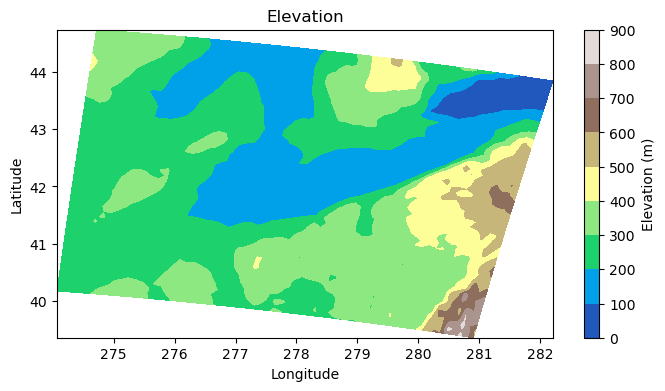

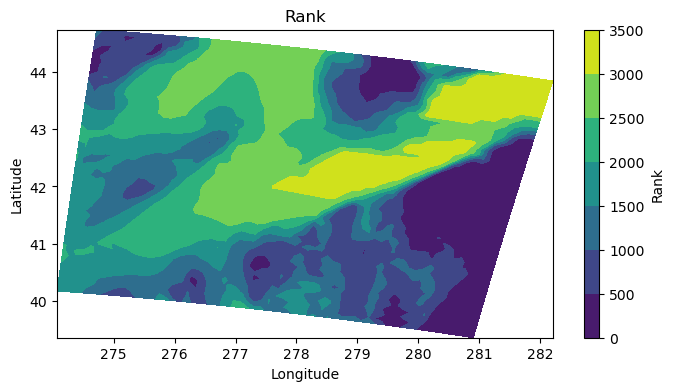

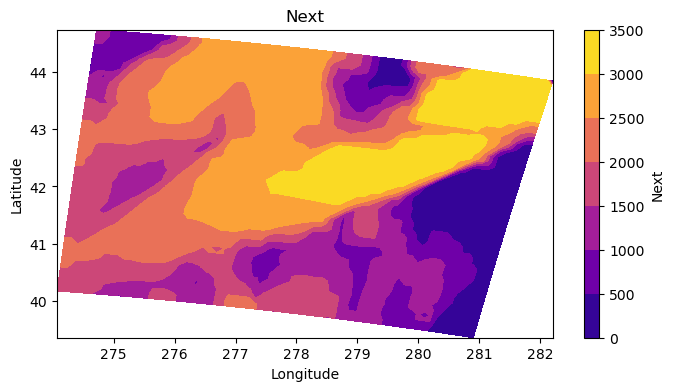

In [14]:
db = xr.open_dataset('MESH_drainage_database_modified.nc')

# Extract the required data
elevation = db['Elev']
rank = db['Rank']
next_var = db['Next']
lat = db['lat']
lon = db['lon']

# Plot the Elevation
plt.figure(figsize=(8, 4))
plt.contourf(lon, lat, elevation, cmap='terrain')
plt.colorbar(label='Elevation (m)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Elevation')
plt.show()

# Plot the Rank
plt.figure(figsize=(8, 4))
plt.contourf(lon, lat, rank, cmap='viridis')
plt.colorbar(label='Rank')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Rank')
plt.show()

# Plot the Next
plt.figure(figsize=(8, 4))
plt.contourf(lon, lat, next_var, cmap='plasma')
plt.colorbar(label='Next')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Next')
plt.show()


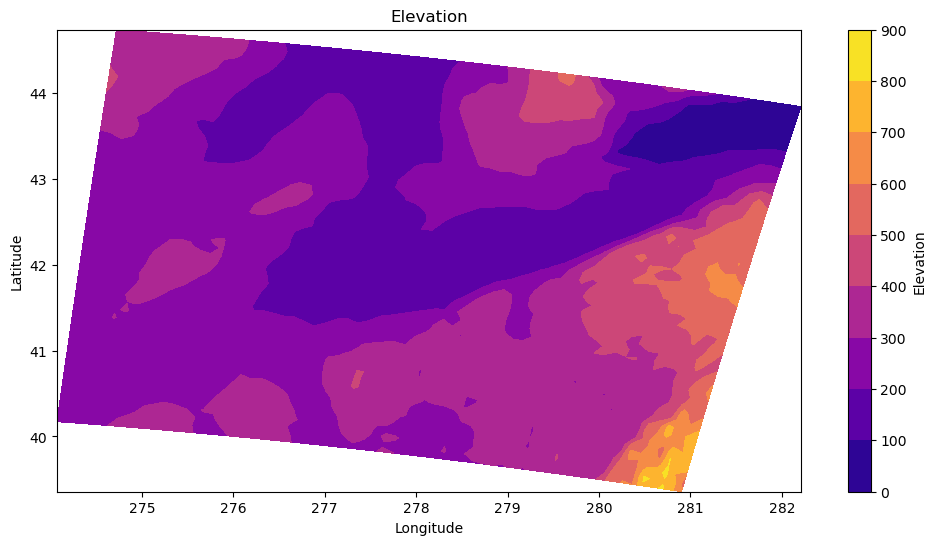

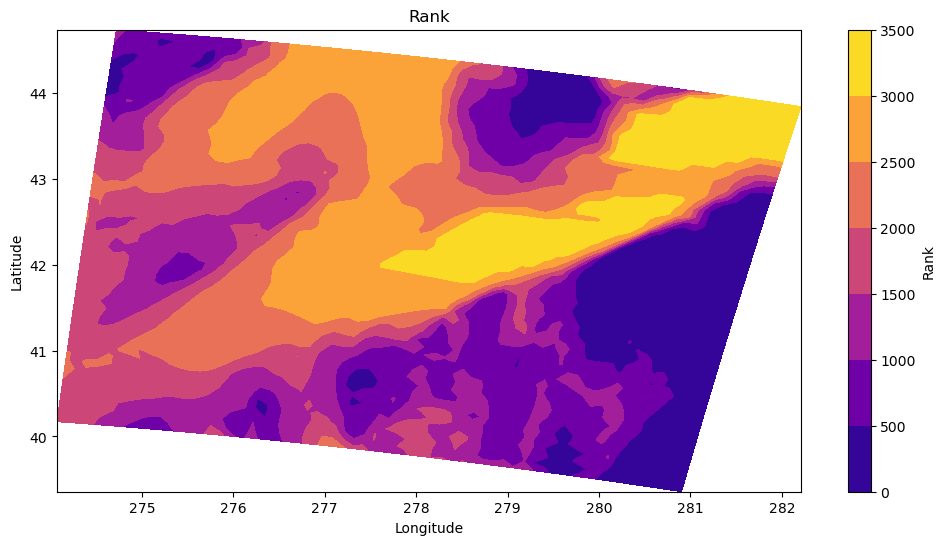

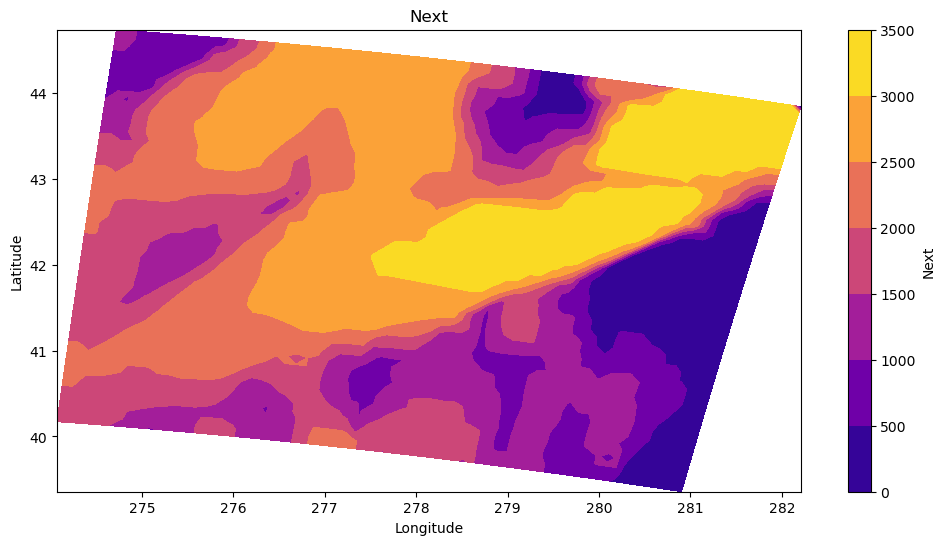

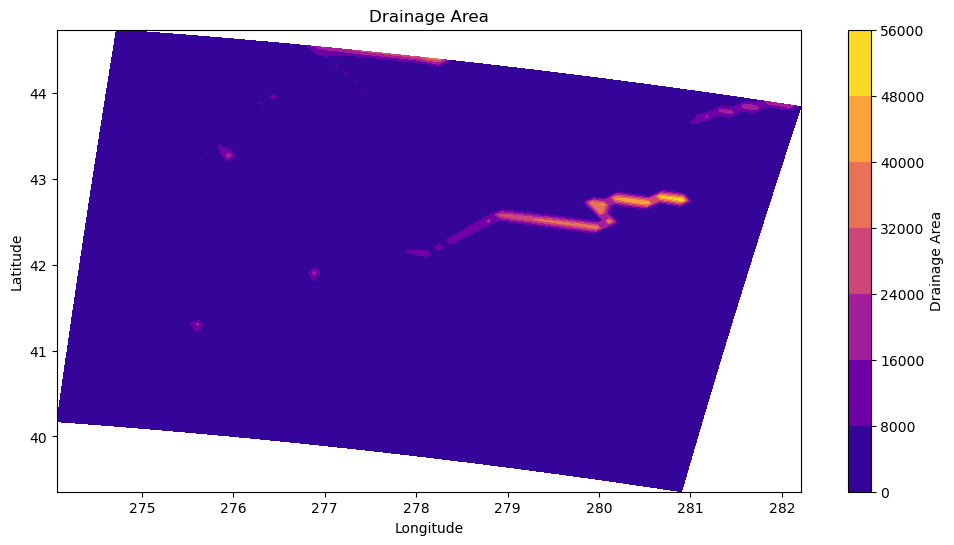

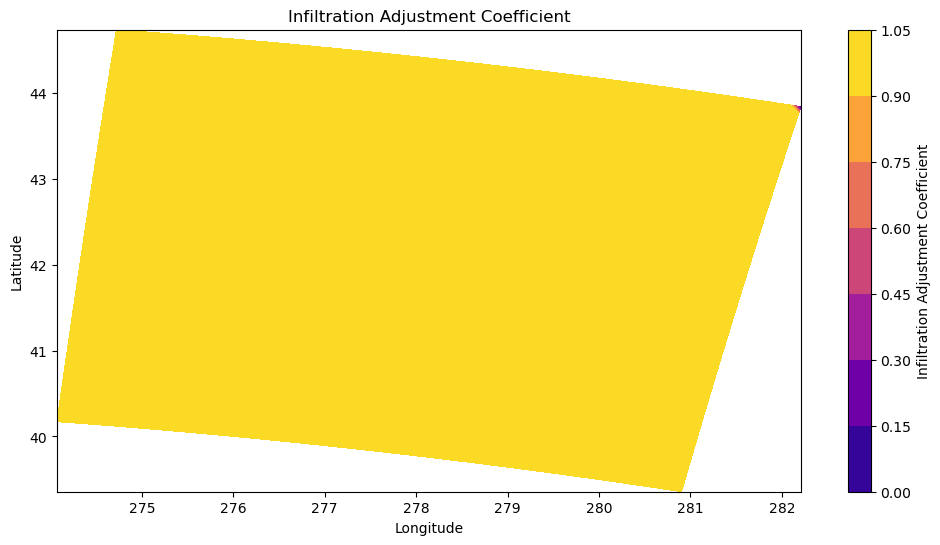

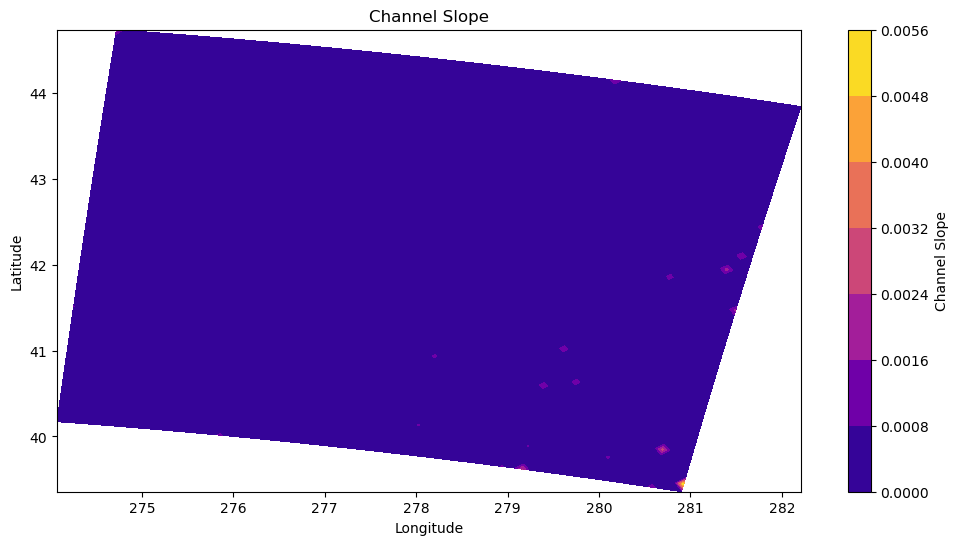

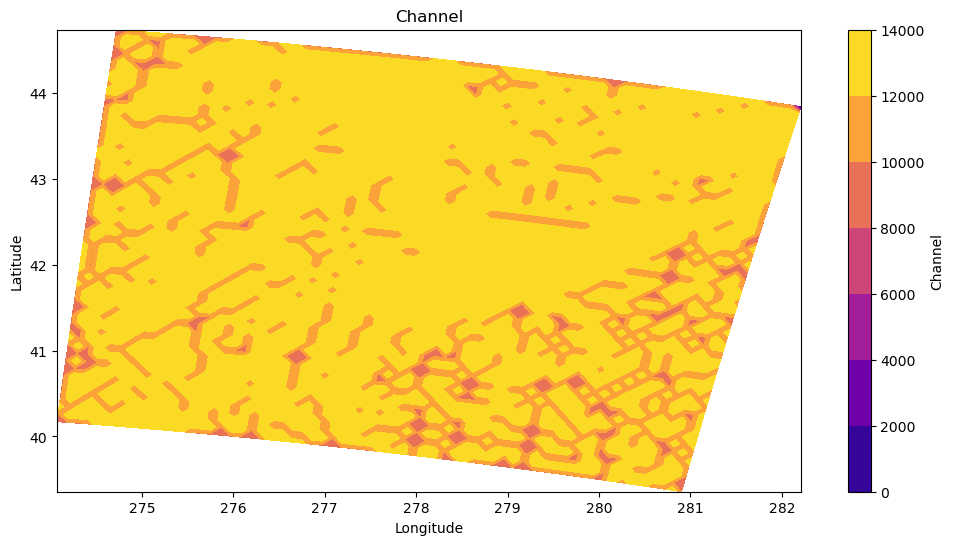

In [15]:
import xarray as xr
import matplotlib.pyplot as plt

# Load the dataset
db = xr.open_dataset('MESH_drainage_database_modified.nc')

# Extract the required data
elevation = db['Elev']
rank = db['Rank']
next_var = db['Next']
da = db['DA']  # Drainage Area
iak = db['IAK']  # Infiltration Adjustment Coefficient
chnl_slope = db['ChnlSlope']  # Channel Slope
chnllength = db['ChnlLength']  # Channel
lat = db['lat']
lon = db['lon']

variables = {
    'Elevation': elevation,
    'Rank': rank,
    'Next': next_var,
    'Drainage Area': da,
    'Infiltration Adjustment Coefficient': iak,
    'Channel Slope': chnl_slope,
    'Channel': chnllength,
}

for name, var in variables.items():
    plt.figure(figsize=(12, 6))
    plt.contourf(lon, lat, var, cmap='plasma')
    plt.colorbar(label=name)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(name)
    plt.show()


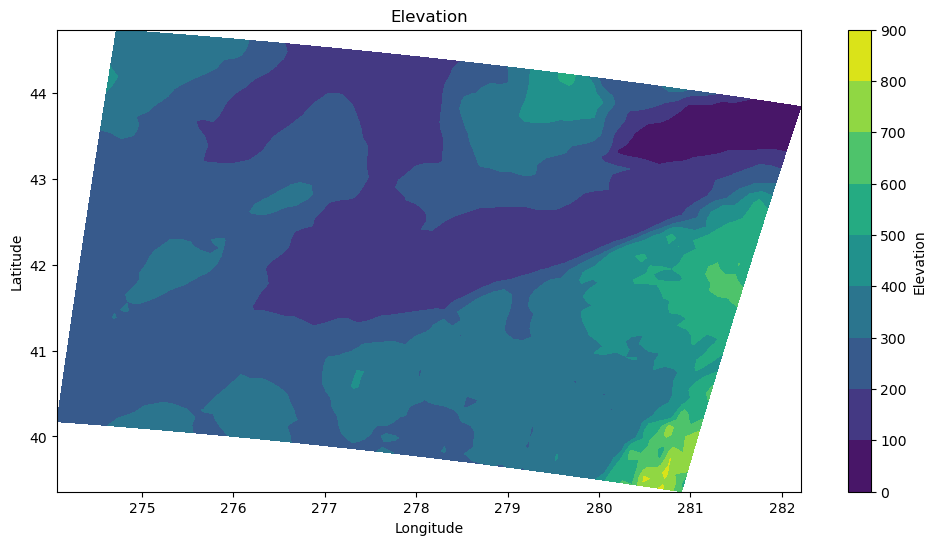

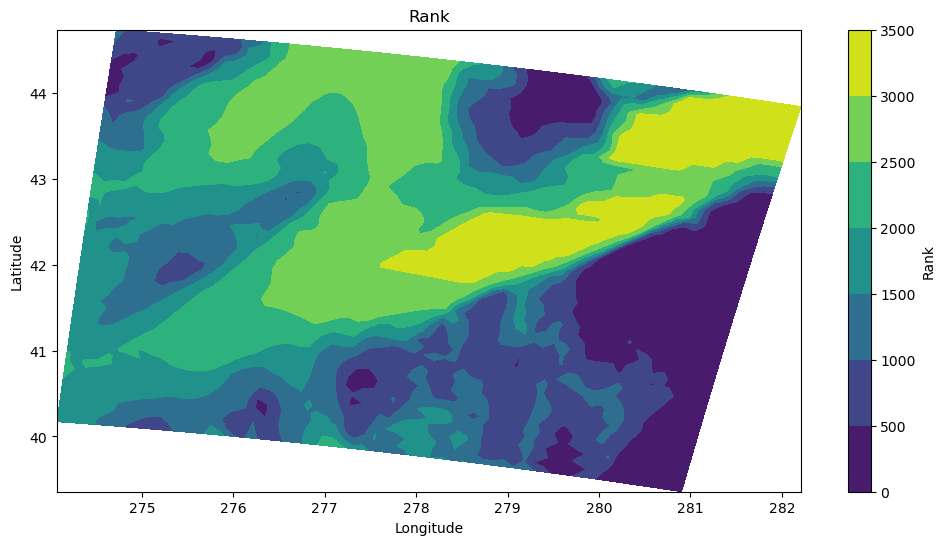

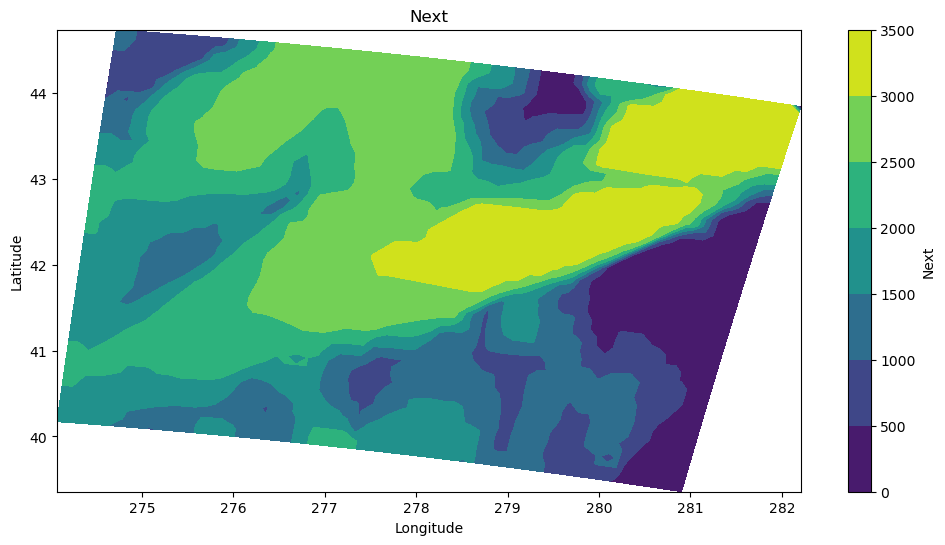

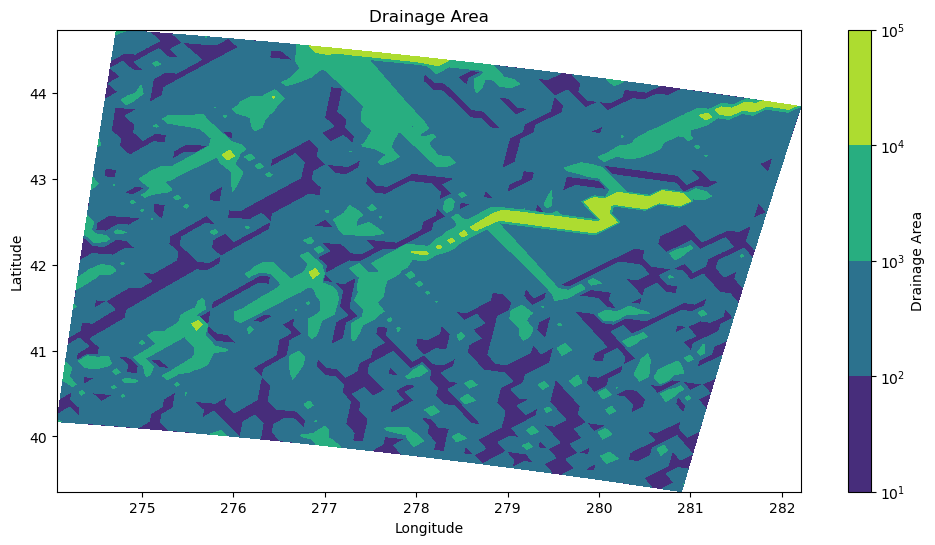

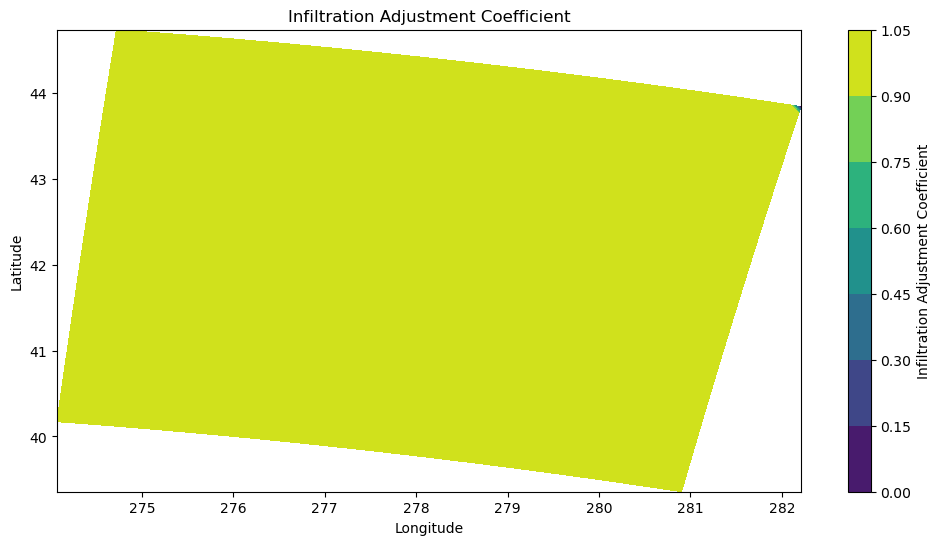

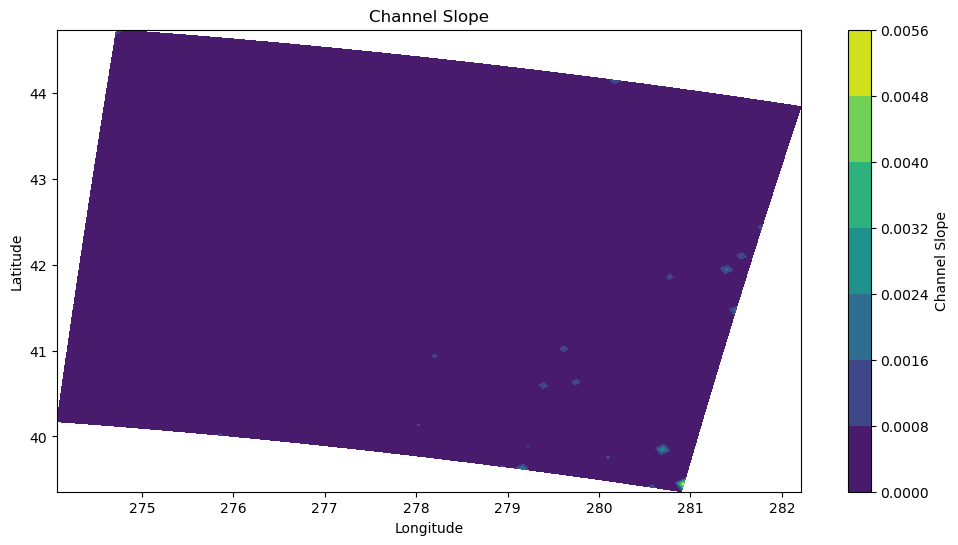

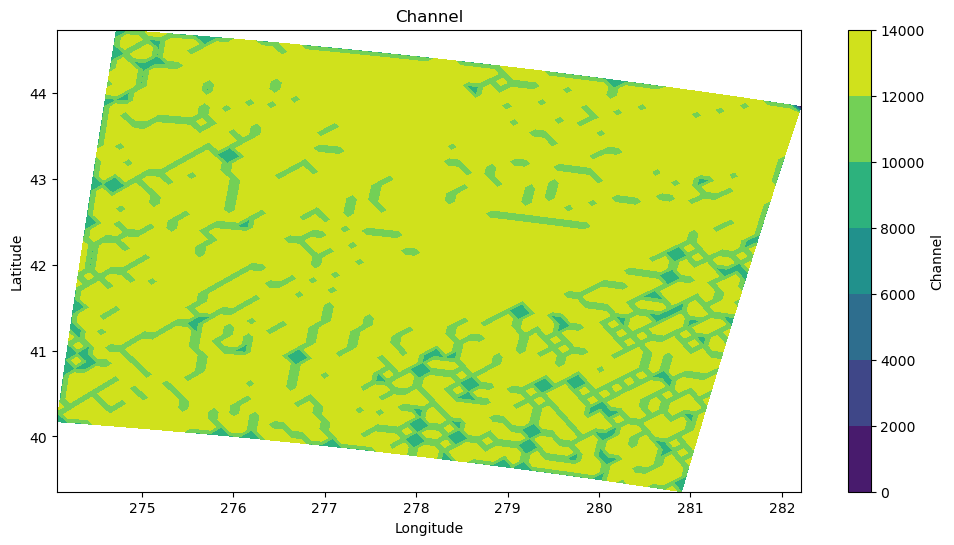

In [16]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Load the dataset
db = xr.open_dataset('MESH_drainage_database_modified.nc')

# Extract the required data
elevation = db['Elev']
rank = db['Rank']
next_var = db['Next']
da = db['DA']  # Drainage Area
iak = db['IAK']  # Infiltration Adjustment Coefficient
chnl_slope = db['ChnlSlope']  # Channel Slope
chnllength = db['ChnlLength']  # Channel
lat = db['lat']
lon = db['lon']

variables = {
    'Elevation': elevation,
    'Rank': rank,
    'Next': next_var,
    'Drainage Area': da,
    'Infiltration Adjustment Coefficient': iak,
    'Channel Slope': chnl_slope,
    'Channel': chnllength,
}

for name, var in variables.items():
    plt.figure(figsize=(12, 6))
    if name == 'Drainage Area':
        plt.contourf(lon, lat, var, norm=LogNorm(), cmap='viridis')
    else:
        plt.contourf(lon, lat, var, cmap='viridis')
    plt.colorbar(label=name)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(name)
    plt.show()


In [ ]:
import xarray as xr
import pandas as pd

# Load the NetCDF file
dataset = xr.open_dataset('MESH_drainage_database.nc')

# Define the function to convert dataset to R2C format
def convert_to_r2c(dataset, filename):
    with open(filename, 'w') as f:
        # Write header information
        f.write("########################################\n")
        f.write(":FileType r2c ASCII EnSim 1.0\n")
        f.write("#\n")
        f.write("# DataType 2D Rect Cell\n")
        f.write("#\n")
        f.write(":Application ensim_utils.py\n")
        f.write(":Version 1.0\n")
        f.write(":WrittenBy ensim_utils.py\n")
        f.write(":CreationDate {}\n".format(pd.Timestamp.now()))
        f.write("#\n")
        f.write("#---------------------------------------\n")
        f.write("#\n")
        f.write("#\n")
        
        for attr, value in dataset.attrs.items():
            f.write(":{} {}\n".format(attr, value))
        
        f.write("#\n")
        f.write(":Projection ROTLATLONG\n")
        f.write(":CentreLatitude 57.0\n")
        f.write(":CentreLongitude 250.0\n")
        f.write(":RotationLatitude 56.0\n")
        f.write(":RotationLongitude 291.0\n")
        f.write(":Ellipsoid SPHERE\n")
        f.write("#\n")
        f.write(":xOrigin 194.624998154\n")
        f.write(":yOrigin -17.8649996963\n")
        f.write("#\n")
        
        attribute_index = 1
        for var_name in dataset.data_vars:
            if var_name == 'GRU':
                for i in range(dataset.dims['ngru']):
                    f.write(":AttributeName {} gru{}\n".format(attribute_index, i+1))
                    f.write(":AttributeUnits {} fraction\n".format(attribute_index))
                    attribute_index += 1
            else:
                f.write(":AttributeName {} {}\n".format(attribute_index, var_name))
                if var_name in ["Rank", "Next", "IAK"]:  # assuming these are integers
                    f.write(":AttributeType {} integer\n".format(attribute_index))
                elif var_name in ["Elev", "GridArea", "Latitude", "Longitude", "IntSlope"]:  # assuming these are floats with units
                    if var_name == "Elev":
                        unit = "m"
                    elif var_name == "GridArea":
                        unit = "m**2"
                    elif var_name in ["Latitude", "Longitude"]:
                        unit = "degrees"
                    elif var_name == "IntSlope":
                        unit = "m m**-1"
                    f.write(":AttributeUnits {} {}\n".format(attribute_index, unit))
                else:
                    f.write(":AttributeUnits {} fraction\n".format(attribute_index))  # default for other variables
                attribute_index += 1

        f.write("#\n")
        f.write(":xCount {}\n".format(dataset.dims['rlon']))
        f.write(":yCount {}\n".format(dataset.dims['rlat']))
        f.write(":xDelta 0.0900000295331\n")
        f.write(":yDelta 0.0900000029919\n")
        f.write("#\n")
        f.write("#\n")
        f.write(":EndHeader\n")
        
        # Loop over each variable and write its data directly
        for var_name, var_data in dataset.data_vars.items():
            if var_name == 'GRU':
                for i in range(dataset.dims['ngru']):
                    for row in var_data.values[i]:
                        f.write(' '.join(map(str, row)) + '\n')
            else:
                if len(var_data.shape) == 2:
                    for row in var_data.values:
                        f.write(' '.join(map(str, row)) + '\n')
                elif len(var_data.shape) == 3:
                    for i in range(var_data.shape[0]):
                        for row in var_data.values[i]:
                            f.write(' '.join(map(str, row)) + '\n')

# Call the function to convert dataset to R2C format
convert_to_r2c(dataset, 'MESH_drainage_database.r2c')


In [ ]:
db 

In [5]:
import xarray as xr
import pandas as pd

# Load the NetCDF file
dataset = xr.open_dataset('MESH_drainage_database.nc')

# Define the function to convert dataset to R2C format
def convert_to_r2c(dataset, filename):
    with open(filename, 'w') as f:
        # Write header information
        f.write("########################################\n")
        f.write(":FileType r2c ASCII EnSim 1.0\n")
        f.write("#\n")
        f.write("# DataType 2D Rect Cell\n")
        f.write("#\n")
        f.write(":Application ensim_utils.py\n")
        f.write(":Version 1.0\n")
        f.write(":WrittenBy ensim_utils.py\n")
        f.write(":CreationDate {}\n".format(pd.Timestamp.now()))
        f.write("#\n")
        f.write("#---------------------------------------\n")
        f.write("#\n")
        f.write("#\n")
        
        for attr, value in dataset.attrs.items():
            f.write(":{} {}\n".format(attr, value))
        
        f.write("#\n")
        f.write(":Projection ROTLATLONG\n")
        f.write(":CentreLatitude 57.0\n")
        f.write(":CentreLongitude 250.0\n")
        f.write(":RotationLatitude 56.0\n")
        f.write(":RotationLongitude 291.0\n")
        f.write(":Ellipsoid SPHERE\n")
        f.write("#\n")
        f.write(":xOrigin 194.624998154\n")
        f.write(":yOrigin -17.8649996963\n")
        f.write("#\n")
        
        attribute_index = 1
        for var_name in dataset.data_vars:
            if var_name == 'GRU':
                for i in range(dataset.dims['NGRU']):
                    f.write(":AttributeName {} gru{}\n".format(attribute_index, i+1))
                    f.write(":AttributeUnits {} fraction\n".format(attribute_index))
                    attribute_index += 1
            else:
                f.write(":AttributeName {} {}\n".format(attribute_index, var_name))
                if var_name in ["Rank", "Next", "IAK", "BadNext", "DDir", "Chnl", "Reach"]:  # assuming these are integers
                    f.write(":AttributeType {} integer\n".format(attribute_index))
                elif var_name in ["Elev", "GridArea", "Latitude", "Longitude", "IntSlope", "DA", "ChnlSlope", "ChnlLength", "Bankfull"]:  # assuming these are floats with units
                    if var_name == "Elev":
                        unit = "m"
                    elif var_name == "GridArea":
                        unit = "m**2"
                    elif var_name in ["Latitude", "Longitude"]:
                        unit = "degrees"
                    elif var_name == "IntSlope":
                        unit = "m m**-1"
                    elif var_name == "DA":
                        unit = "m**2"
                    elif var_name == "ChnlSlope":
                        unit = "m m**-1"
                    elif var_name == "ChnlLength":
                        unit = "m"
                    elif var_name == "Bankfull":
                        unit = "m"
                    f.write(":AttributeUnits {} {}\n".format(attribute_index, unit))
                else:
                    f.write(":AttributeUnits {} fraction\n".format(attribute_index))  # default for other variables
                attribute_index += 1

        f.write("#\n")
        f.write(":xCount {}\n".format(dataset.dims['rlon']))
        f.write(":yCount {}\n".format(dataset.dims['rlat']))
        f.write(":xDelta 0.0900000295331\n")
        f.write(":yDelta 0.0900000029919\n")
        f.write("#\n")
        f.write("#\n")
        f.write(":EndHeader\n")
        
        # Loop over each variable and write its data directly
        for var_name, var_data in dataset.data_vars.items():
            if var_name == 'GRU':
                for i in range(dataset.dims['NGRU']):
                    for row in var_data.values[i]:
                        f.write(' '.join(map(str, row)) + '\n')
            else:
                if len(var_data.shape) == 2:
                    for row in var_data.values:
                        f.write(' '.join(map(str, row)) + '\n')
                elif len(var_data.shape) == 3:
                    for i in range(var_data.shape[0]):
                        for row in var_data.values[i]:
                            f.write(' '.join(map(str, row)) + '\n')

# Call the function to convert dataset to R2C format
convert_to_r2c(dataset, 'MESH_drainage_database.r2c')


C:\Users\TesemmaZ\AppData\Local\Temp\ipykernel_30268\544423855.py:43: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(dataset.dims['NGRU']):
C:\Users\TesemmaZ\AppData\Local\Temp\ipykernel_30268\544423855.py:74: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  f.write(":xCount {}\n".format(dataset.dims['rlon']))
C:\Users\TesemmaZ\AppData\Local\Temp\ipykernel_30268\544423855.py:75: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension nam